In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from kuramoto.config import (
    SimulationConfig,
    GridConfig,
    CouplingConfig,
    InitThetaConfig,
    InitOmegaConfig,
    KernelComponentConfig,
    build_simulation,
)
from kuramoto.coupling import apply_node_lesions, plot_lesioned_coupling
from kuramoto.simulation import KuramotoParams
from kuramoto.analysis import (
    order_parameter, 
    compute_effective_coupling, 
    avg_effective_coupling,
    functional_connectivity,
    R_link,
)
from kuramoto.adjoint import (
    grads_final_R,
    grads_mean_R,
    node_importance_from_gradK,
    grads_final_R_alpha,
    grads_mean_R_alpha,
    plot_basic_grads,
    plot_advanced_grads,
)
from kuramoto.plotting import plot_2d, plot_coupling_matrix
from kuramoto.network import (
    create_cortical_graph,
    plot_graph_metrics,
    get_graph_metrics,
    plot_metric,
)
from kuramoto.experiments import run_lesion_study

from jax import numpy as jnp

SEED = 42
grid_shape = (12, 12)
N = grid_shape[0] * grid_shape[1]
T_END = 10.0
dt = 0.01

RNG = np.random.default_rng(SEED)


n_rows, n_cols = grid_shape

group_ids = np.zeros((n_rows, n_cols), dtype=int)
group_ids[n_rows // 2 :, :] = 1 # Top half is group 1, bottom half is group 0
group_ids[n_rows // 2 -2: n_rows // 2 +2, n_cols // 2 -2: n_cols // 2 +2] = 2 # 3x3 block in center is group 2
group_ids = group_ids.ravel().tolist()

components = [
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=1.0,
        kernel_params={"sigma": 1.0},
        radius=2.0,
        node_groups=[0],
        edge_mode="within",
    ),
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=1.0,
        kernel_params={"sigma": 1.0},
        radius=2.0,
        node_groups=[1],
        edge_mode="within",
    ),
    KernelComponentConfig( # Fully connected coupling from group 2 to groups 0 and 1
        kernel="gaussian",
        base_strength=0.8,
        kernel_params={"sigma": 4.0},
        radius=4.0,
        node_groups=[2],
        edge_mode="outgoing",
    ),
    KernelComponentConfig( 
        kernel="gaussian",
        base_strength=0.8,
        kernel_params={"sigma": 4.0},
        radius=4.0,
        node_groups=[2],
        edge_mode="incoming",
    ),
    KernelComponentConfig( # weak one way coupling from group 1 to group 0
        kernel="gaussian",
        base_strength=0.2,
        kernel_params={"sigma": 2.0},
        radius=2.0,
        node_groups=[1],
        edge_mode="custom",
        to_node_groups=[0],
    ),
]

cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(
        kernel="gaussian",
        base_strength=1.0,
        radius=4.0,
        mode="spatial",
        components=components,
        group_ids=group_ids,
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=42,
)

sim = build_simulation(config=cfg, rng=np.random.default_rng(SEED))

# Run base simulation
res_base = sim.run((0, T_END), dt, rng=RNG)

# Create graphs
G = create_cortical_graph(sim)

K_eff_avg = avg_effective_coupling(sim.results["theta"], sim.coupling.K)
G_eff = create_cortical_graph(K_eff_avg, omega=sim.params.omega)

C_avg = functional_connectivity(sim.results["theta"], dt=dt)
G_C_avg = create_cortical_graph(C_avg, omega=sim.params.omega)

In [2]:
graph_metrics = get_graph_metrics(G)
graph_metrics_eff = get_graph_metrics(G_eff)
graph_metrics_C_avg = get_graph_metrics(G_C_avg)

# plot_graph_metrics(graph_metrics,grid_shape=grid_shape,title="Base coupling network metrics")
# plot_graph_metrics(graph_metrics_eff,grid_shape=grid_shape,title="Effective coupling network metrics")
# plot_graph_metrics(graph_metrics_C_avg,grid_shape=grid_shape,title="Functional connectivity network metrics")

### 2) Adjoint metrics

In [3]:
t0, t1 = 0.0, T_END
ts = jnp.arange(t0, t1 + dt / 2, dt)
ts = ts[ts <= t1]

g = grads_final_R(sim.params, sim.theta0, t0=0.0, t1=T_END, dt=dt, ts=[T_END])
g_avg = grads_mean_R(sim.params, sim.theta0, t0=0.0, t1=T_END, dt=dt, ts=ts)

# plot_basic_grads(g,grid_shape,title="Basic gradients (J = R_final)")
# plot_basic_grads(g_avg,grid_shape,title="Basic gradients (J = R_mean)")

In [4]:
I_final = node_importance_from_gradK(sim.params.K, g.K)
I_mean = node_importance_from_gradK(sim.params.K, g_avg.K)

alpha0 = jnp.zeros((sim.grid.N,), dtype=sim.params.K.dtype)
dRf_dalpha = grads_final_R_alpha(sim.params, alpha0, sim.theta0, t0, t1, dt, ts=ts)
dRm_dalpha = grads_mean_R_alpha(sim.params, alpha0, sim.theta0, t0, t1, dt, ts=ts)

#Statistics
print(f"  max I_final: {float(np.max(I_final)):.6e}")
print(f"  max I_mean: {float(np.max(I_mean)):.6e}")
print(f"  max |dRf/dalpha| = {float(np.max(np.abs(dRf_dalpha))):.6e}")
print(f"  max |dRm/dalpha| = {float(np.max(np.abs(dRm_dalpha))):.6e}")

#Plot
# plot_advanced_grads(dRf_dalpha, I_final, grid_shape, title="Node importance (J = R_final)")
# plot_advanced_grads(dRm_dalpha, I_mean, grid_shape, title="Node importance (J = R_mean)")

  max I_final: 2.463365e-03
  max I_mean: 5.458221e-02
  max |dRf/dalpha| = 2.463365e-03
  max |dRm/dalpha| = 5.458221e-02


## Lesion Studies

In [34]:
# Assemble all metrics into a single dictionary
metrics = {
    "deg_base": graph_metrics["deg_cent"],
    "deg_eff": graph_metrics_eff["deg_cent"],
    "deg_C_avg": graph_metrics_C_avg["deg_cent"],
    "closeness_base": graph_metrics["closeness"],
    "closeness_eff": graph_metrics_eff["closeness"],
    "closeness_C_avg": graph_metrics_C_avg["closeness"],
    "betweenness_base": graph_metrics["betweenness"],
    "betweenness_eff": graph_metrics_eff["betweenness"],
    "betweenness_C_avg": graph_metrics_C_avg["betweenness"],
    "eigenvector_base": graph_metrics["eigenvector"],
    "eigenvector_eff": graph_metrics_eff["eigenvector"],
    "eigenvector_C_avg": graph_metrics_C_avg["eigenvector"],
    "I_final_base": I_final,
    "I_final_eff": I_mean,
    "I_mean_base": I_mean,
    "I_mean_eff": I_final,
    "dRf_dalpha": dRf_dalpha,
    "dRm_dalpha": dRm_dalpha,
}

K_base = sim.coupling.K
params_orig = sim.params

N_RANDOM_REPEATS = 5

### Single metric lesion study

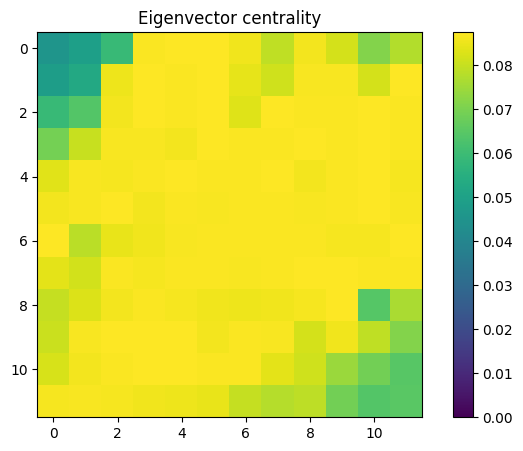

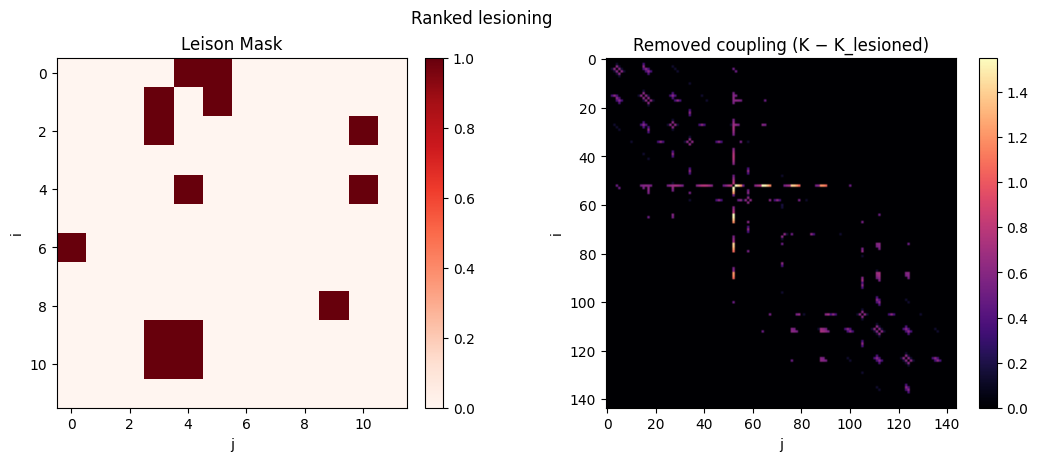

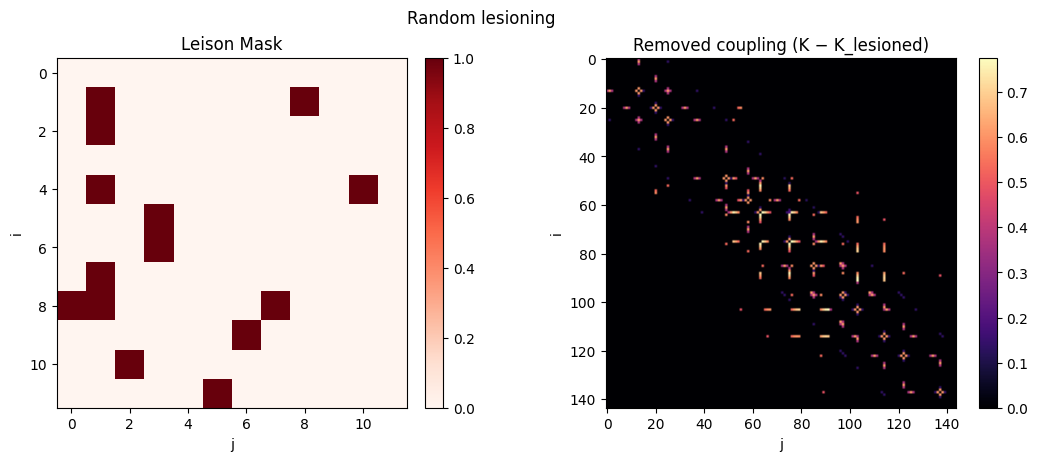

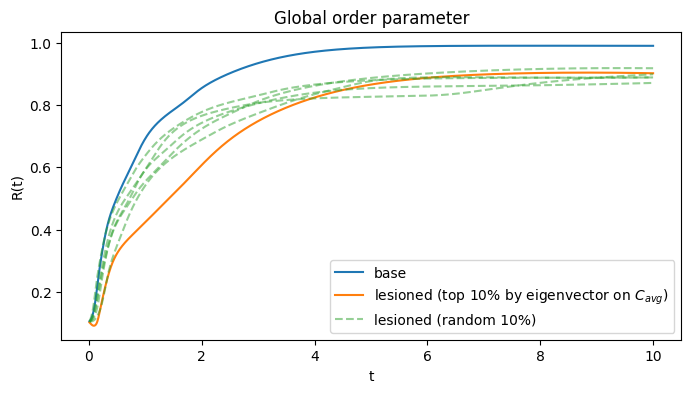

In [40]:
metric = graph_metrics_C_avg["eigenvector"]

plot_metric(metric, grid_shape, "Eigenvector centrality")

lesion_frac = 0.10
lesion_strength = 1.0 # lesion strength (1.0 = remove all connections)

# Lesion top x% of nodes by metric
res_ranked_lesion, alpha_ranked, K_lesioned_ranked = run_lesion_study(sim, metric, lesion_frac, lesion_strength, T_END, dt, RNG)
plot_lesioned_coupling(alpha_ranked, K_base, K_lesioned_ranked, grid_shape, title="Ranked lesioning")

# Lesion 10% of nodes randomly
R_random_lesion = np.zeros((len(ts), N_RANDOM_REPEATS))
for i in range(N_RANDOM_REPEATS):
    res_random_lesion, alpha_random, K_lesioned_random = run_lesion_study(sim, "random", lesion_frac, lesion_strength, T_END, dt, RNG)
    R_random_lesion[:, i] = order_parameter(res_random_lesion["theta"])[0]
plot_lesioned_coupling(alpha_random, K_base, K_lesioned_random, grid_shape, title="Random lesioning")

# Compare R vs t for base and lesioned sim
R_base, _ = order_parameter(res_base["theta"])
R_ranked_lesion, _ = order_parameter(res_ranked_lesion["theta"])
ts = res_base["ts"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ts, R_base, label="base")
ax.plot(ts, R_ranked_lesion, label=f"lesioned (top {lesion_frac:.0%} by eigenvector on $C_{{avg}}$)")
for i in range(N_RANDOM_REPEATS):
    if i == 0:
        ax.plot(ts, R_random_lesion[:, i], label=f"lesioned (random {lesion_frac:.0%})", linestyle="--", color="C2", alpha=0.5)
    else:
        ax.plot(ts, R_random_lesion[:, i], linestyle="--", color="C2", alpha=0.5)
ax.set_xlabel("t")
ax.set_ylabel("R(t)")
ax.set_title("Global order parameter")
ax.legend()
plt.show()

Text(0.5, 0.98, 'R vs degradation for ranked vs random lesioning')

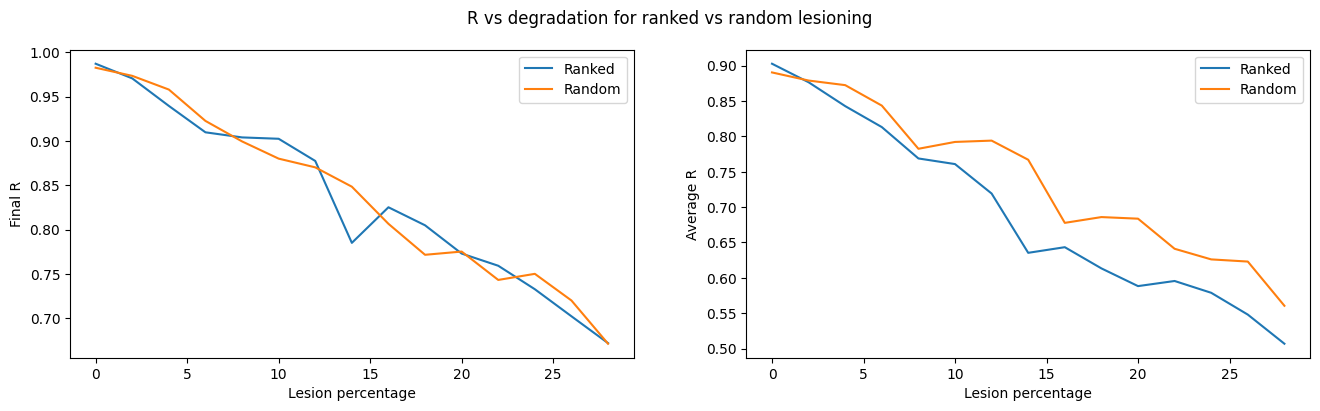

In [ ]:
# Compute R final/ R_avg vs lesion %
lesion_fracs = np.arange(0, 0.3, 0.02)

R_final_ranked = []
R_avg_ranked = []
R_final_random = []
R_avg_random = []

for lesion_frac in lesion_fracs:
    res_ranked_lesion, alpha_ranked, K_lesioned_ranked = run_lesion_study(sim, metric, lesion_frac, lesion_strength, T_END, dt, RNG)
    R_ranked_lesion, _ = order_parameter(res_ranked_lesion["theta"])

    R_random_lesion = np.zeros((len(ts), N_RANDOM_REPEATS))
    for i in range(N_RANDOM_REPEATS):
        res_random_lesion, alpha_random, K_lesioned_random = run_lesion_study(sim, "random", lesion_frac, lesion_strength, T_END, dt, RNG)
        R_random_lesion[:, i], _ = order_parameter(res_random_lesion["theta"])
    R_random_lesion = np.mean(R_random_lesion, axis=1)

    R_final_ranked.append(R_ranked_lesion[-1])
    R_avg_ranked.append(np.mean(R_ranked_lesion))
    R_final_random.append(R_random_lesion[-1])
    R_avg_random.append(np.mean(R_random_lesion))

fig, ax = plt.subplots(1,2, figsize=(16, 4))
ax[0].plot(lesion_fracs*100, R_final_ranked, label="Ranked")
ax[0].plot(lesion_fracs*100, R_final_random, label="Random")
ax[0].set_xlabel("Lesion percentage")
ax[0].set_ylabel("Final R")
ax[0].legend()

ax[1].plot(lesion_fracs*100, R_avg_ranked, label="Ranked")
ax[1].plot(lesion_fracs*100, R_avg_random, label="Random")
ax[1].set_xlabel("Lesion percentage")
ax[1].set_ylabel("Average R")
ax[1].legend()
fig.suptitle("R vs degradation for ranked vs random lesioning")

In [42]:
# Compute node importance metric scores
# 1) Area under degradation curve (AUC) - Lower AUC means better metric (performance degrades faster)
AUC_ranked = np.trapezoid(R_avg_ranked, lesion_fracs)
AUC_random = np.trapezoid(R_avg_random, lesion_fracs)

# 2) Area between random and ranked curves (ABC) - higher ABC means better metric (outperforms random lesioning)
ABC = AUC_random - AUC_ranked

print(f"AUC_ranked: {AUC_ranked:.4f}")
print(f"AUC_random: {AUC_random:.4f}")
print(f"ABC: {ABC:.4f}")

AUC_ranked: 0.1938
AUC_random: 0.2079
ABC: 0.0141


### Evaluate on all metrics

In [43]:
# Run lesion study for each metric
metric_scores = {}
for metric_name, metric in metrics.items():
    print(f"Evaluating {metric_name}...")

    R_final_ranked = []
    R_avg_ranked = []
    R_final_random = []
    R_avg_random = []
    for lesion_frac in lesion_fracs:
        res_ranked_lesion, alpha_ranked, K_lesioned_ranked = run_lesion_study(sim, metric, lesion_frac, lesion_strength, T_END, dt, RNG)
        R_ranked_lesion, _ = order_parameter(res_ranked_lesion["theta"])

        R_random_lesion = np.zeros((len(ts), N_RANDOM_REPEATS))
        for i in range(N_RANDOM_REPEATS):
            res_random_lesion, alpha_random, K_lesioned_random = run_lesion_study(sim, "random", lesion_frac, lesion_strength, T_END, dt, RNG)
            R_random_lesion[:, i], _ = order_parameter(res_random_lesion["theta"])
        R_random_lesion = np.mean(R_random_lesion, axis=1)

        R_final_ranked.append(R_ranked_lesion[-1])
        R_avg_ranked.append(np.mean(R_ranked_lesion))
        R_final_random.append(R_random_lesion[-1])
        R_avg_random.append(np.mean(R_random_lesion))

    # Metric scores
    AUC_ranked = np.trapezoid(R_avg_ranked, lesion_fracs)
    AUC_random = np.trapezoid(R_avg_random, lesion_fracs)
    ABC = AUC_random - AUC_ranked

    metric_scores[metric_name] = {
        "AUC_ranked": AUC_ranked,
        "AUC_random": AUC_random,
        "ABC": ABC,
        "R_final_ranked": R_final_ranked,
        "R_avg_ranked": R_avg_ranked,
        "R_final_random": R_final_random,
        "R_avg_random": R_avg_random,
    }

Evaluating deg_base...
Evaluating deg_eff...
Evaluating deg_C_avg...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating closeness_C_avg...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating betweenness_C_avg...
Evaluating eigenvector_base...
Evaluating eigenvector_eff...
Evaluating eigenvector_C_avg...
Evaluating I_final_base...
Evaluating I_final_eff...
Evaluating I_mean_base...
Evaluating I_mean_eff...
Evaluating dRf_dalpha...
Evaluating dRm_dalpha...


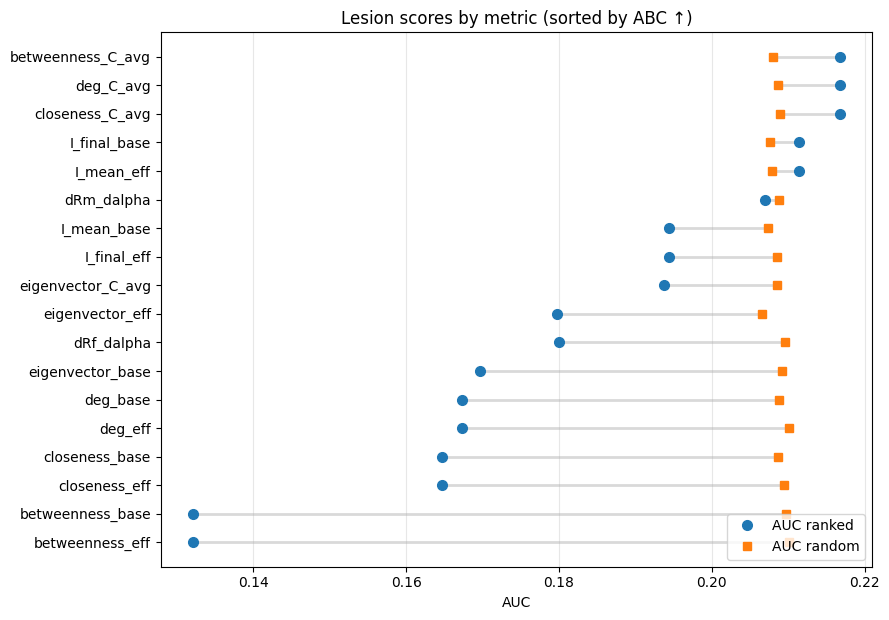

In [44]:
import numpy as np
import matplotlib.pyplot as plt

metrics = list(metric_scores.keys())
# Higher ABC = better (flip to minus if lower is better)
order = sorted(metrics, key=lambda m: metric_scores[m]["ABC"])

y = np.arange(len(order))
auc_r = np.array([metric_scores[m]["AUC_ranked"] for m in order])
auc_rand = np.array([metric_scores[m]["AUC_random"] for m in order])

fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(order))))
ax.hlines(y, np.minimum(auc_r, auc_rand), np.maximum(auc_r, auc_rand), color="0.85", lw=2, zorder=0)
ax.plot(auc_r, y, "o", ms=7, label="AUC ranked", zorder=2, color="C0")
ax.plot(auc_rand, y, "s", ms=6, label="AUC random", zorder=2, color="C1")
ax.set_yticks(y, order)
ax.set_xlabel("AUC")
ax.set_title("Lesion scores by metric (sorted by ABC ↑)")
ax.legend(loc="lower right")
ax.invert_yaxis()  # best ABC at top
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

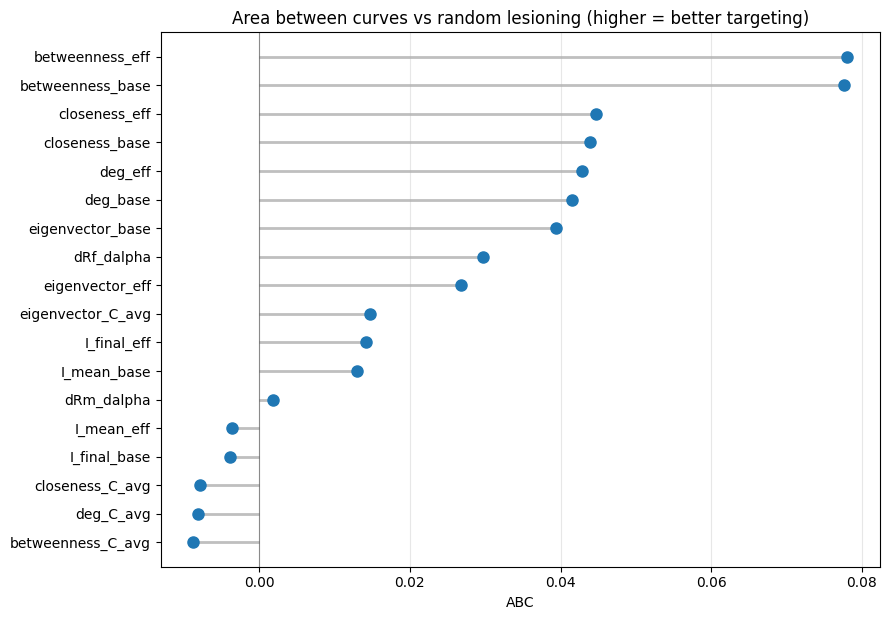

In [45]:
import numpy as np
import matplotlib.pyplot as plt

metrics = list(metric_scores.keys())
# Higher ABC = better (use reverse=False / invert_yaxis as below)
order = sorted(metrics, key=lambda m: metric_scores[m]["ABC"])
abc = np.array([metric_scores[m]["ABC"] for m in order])

y = np.arange(len(order))

fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(order))))
# Lollipop: stem + dot
ax.hlines(y, 0, abc, color="0.75", lw=2, zorder=1)
ax.plot(abc, y, "o", ms=8, color="C0", zorder=2, clip_on=False)

ax.set_yticks(y, order)
ax.set_xlabel("ABC")
ax.set_title("Area between curves vs random lesioning (higher = better targeting)")
ax.axvline(0, color="k", lw=0.8, alpha=0.4)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()